In [1]:
import pandas as pd
import numpy as np
from nbconvert import export

In [2]:
#Loading in the roads data file
df1 = pd.read_csv('../data/_roads3.csv')
# print(df1.head())

#Filtering on only the N1 road
dfN1 = df1[df1['road'] == 'N1']

In [3]:
#Creating the source and sink for the new data frame, based on the minimal and maximal chainage
source_val = dfN1['chainage'].min()
sink_val = dfN1['chainage'].max()
source_row = dfN1[dfN1['chainage'] == source_val].head(1)
sink_row = dfN1[dfN1['chainage'] == sink_val].head(1)

In [4]:
#Creating a new DataFrame with the source and sink
df_proc = pd.concat([source_row, sink_row]).drop_duplicates(subset=['chainage', 'lrp']).sort_values('chainage').reset_index(drop=True)

In [5]:
df_proc

,road,chainage,lrp,lat,lon,gap,type,name
0,N1,0.000,LRPS,23.706028,90.443333,NaN,Others,Start of Road after Jatrabari Flyover infront...
1,N1,462.254,LRPE,20.862917,92.298083,NaN,Others,"End of Road at Shapla Chattar ,Teknaf Meet wit..."


In [6]:
#Loading in the Bridges data
df_BMMS = pd.read_excel('../data/BMMS_overview.xlsx')

In [7]:
#Selecting the columns that we need
cols = [
    "road",
    "name",
    "LRPName",
    "length",
    "chainage",
    "lat",
    "lon",
    "condition",
]

bridges_BMMS = df_BMMS[cols].copy()
bridges_BMMS = bridges_BMMS[bridges_BMMS['road'] == 'N1']

In [8]:
bridges_BMMS.head(20)

,road,name,LRPName,length,chainage,lat,lon,condition
0,N1,.,LRP001a,11.30,1.800,23.698739,90.458861,A
1,N1,.,LRP004b,6.60,4.925,23.694664,90.487775,A
2,N1,Kanch pur Bridge.,LRP008b,394.23,8.976,23.705060,90.523214,A
3,N1,NOYAPARA CULVERT,LRP010b,6.30,10.880,23.694391,90.537574,A
4,N1,ADUPUR CULVERT,LRP010c,6.30,10.897,23.694302,90.537707,A
5,N1,NAYABARI KASPUR BOX CULVERT,LRP011a,8.30,11.296,23.692360,90.540918,A
6,N1,KHAS PARA BOX CULVERT,LRP012a,9.30,12.239,23.688412,90.548559,A
7,N1,DAWAN BAG BOX CULVERT,LRP012b,6.10,12.253,23.688320,90.548650,A
8,N1,Madanpur Bridge.(L),LRP013a,27.50,12.660,23.685583,90.551208,A
9,N1,MADAN PUR (R),LRP013a,26.30,12.660,23.685583,90.551208,A


In [9]:
#Preprocessing names of bridges so they are more uniform for later duplicates deletion
bridges_BMMS['name_clean'] = bridges_BMMS['name'].astype(str).str.replace(' ', '').str.upper()
#Rounding the location of bridges in order to delete duplicates that are really close together later
bridges_BMMS['lat_round'] = bridges_BMMS['lat'].round(4)
bridges_BMMS['lon_round'] = bridges_BMMS['lon'].round(4)

In [10]:
bridges_BMMS.info()

<class 'pandas.core.frame.DataFrame'>
Index: 787 entries, 0 to 19382
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   road        787 non-null    object 
 1   name        787 non-null    object 
 2   LRPName     787 non-null    object 
 3   length      787 non-null    float64
 4   chainage    787 non-null    float64
 5   lat         787 non-null    float64
 6   lon         787 non-null    float64
 7   condition   787 non-null    object 
 8   name_clean  787 non-null    object 
 9   lat_round   787 non-null    float64
 10  lon_round   787 non-null    float64
dtypes: float64(6), object(5)
memory usage: 73.8+ KB


In [11]:
#Dropping duplicates
df_unique = bridges_BMMS.drop_duplicates(subset=['chainage', 'lat_round', 'lon_round'], keep='first')

In [12]:
df_unique.info()

<class 'pandas.core.frame.DataFrame'>
Index: 628 entries, 0 to 19382
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   road        628 non-null    object 
 1   name        628 non-null    object 
 2   LRPName     628 non-null    object 
 3   length      628 non-null    float64
 4   chainage    628 non-null    float64
 5   lat         628 non-null    float64
 6   lon         628 non-null    float64
 7   condition   628 non-null    object 
 8   name_clean  628 non-null    object 
 9   lat_round   628 non-null    float64
 10  lon_round   628 non-null    float64
dtypes: float64(6), object(5)
memory usage: 58.9+ KB


In [13]:
df_unique.reset_index(drop=True, inplace=True)
df_unique

,road,name,LRPName,length,chainage,lat,lon,condition,name_clean,lat_round,lon_round
0,N1,.,LRP001a,11.30,1.800,23.698739,90.458861,A,.,23.6987,90.4589
1,N1,.,LRP004b,6.60,4.925,23.694664,90.487775,A,.,23.6947,90.4878
2,N1,Kanch pur Bridge.,LRP008b,394.23,8.976,23.705060,90.523214,A,KANCHPURBRIDGE.,23.7051,90.5232
3,N1,NOYAPARA CULVERT,LRP010b,6.30,10.880,23.694391,90.537574,A,NOYAPARACULVERT,23.6944,90.5376
4,N1,ADUPUR CULVERT,LRP010c,6.30,10.897,23.694302,90.537707,A,ADUPURCULVERT,23.6943,90.5377
...,...,...,...,...,...,...,...,...,...,...,...
623,N1,MORICHIA,LRP394a,11.20,397.591,21.321109,92.088884,D,MORICHIA,21.3211,92.0889
624,N1,SHAPUR STEEL BEAM AND RCC SLAB,LRP396b,61.30,400.460,21.299745,92.097477,D,SHAPURSTEELBEAMANDRCCSLAB,21.2997,92.0975
625,N1,Balukhali Boro Bridge,LRP413b,15.40,417.290,21.188892,92.165877,D,BALUKHALIBOROBRIDGE,21.1889,92.1659
626,N1,Kata Khali Bridge,LRP421a,12.30,424.577,21.137612,92.168059,D,KATAKHALIBRIDGE,21.1376,92.1681


In [14]:
#Filtering on bridges only
df_unique['model_type'] = 'bridge'

export_df = df_unique[['road', 'LRPName', 'model_type', 'name', 'lat', 'lon','length', 'condition', 'chainage']]
export_df.rename(columns={'LRPName': 'id'}, inplace=True)
export_df.head(10)

C:\Users\lieke\AppData\Local\Temp\ipykernel_15108\1808525536.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_unique['model_type'] = 'bridge'
C:\Users\lieke\AppData\Local\Temp\ipykernel_15108\1808525536.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  export_df.rename(columns={'LRPName': 'id'}, inplace=True)


,road,id,model_type,name,lat,lon,length,condition,chainage
0,N1,LRP001a,bridge,.,23.698739,90.458861,11.30,A,1.800
1,N1,LRP004b,bridge,.,23.694664,90.487775,6.60,A,4.925
2,N1,LRP008b,bridge,Kanch pur Bridge.,23.705060,90.523214,394.23,A,8.976
3,N1,LRP010b,bridge,NOYAPARA CULVERT,23.694391,90.537574,6.30,A,10.880
4,N1,LRP010c,bridge,ADUPUR CULVERT,23.694302,90.537707,6.30,A,10.897
5,N1,LRP011a,bridge,NAYABARI KASPUR BOX CULVERT,23.692360,90.540918,8.30,A,11.296
6,N1,LRP012a,bridge,KHAS PARA BOX CULVERT,23.688412,90.548559,9.30,A,12.239
7,N1,LRP012b,bridge,DAWAN BAG BOX CULVERT,23.688320,90.548650,6.10,A,12.253
8,N1,LRP013a,bridge,Madanpur Bridge.(L),23.685583,90.551208,27.50,A,12.660
9,N1,LRP013b,bridge,Madanpur Bridge(R),23.685362,90.551359,27.50,A,12.688


In [15]:
#Manually adding source and sink
df_proc.loc[df_proc.index[0], 'model_type'] = 'source'
df_proc.loc[df_proc.index[-1], 'model_type'] = 'sink'
df_proc['length'] = 0
df_proc['condition'] = None
df_proc = df_proc[['road', 'lrp', 'model_type', 'name', 'lat', 'lon', 'length', 'condition', 'chainage']]
df_proc.rename(columns={'lrp':'id'}, inplace=True)


C:\Users\lieke\AppData\Local\Temp\ipykernel_15108\843178568.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_proc.rename(columns={'lrp':'id'}, inplace=True)


In [16]:
df_proc

,road,id,model_type,name,lat,lon,length,condition,chainage
0,N1,LRPS,source,Start of Road after Jatrabari Flyover infront...,23.706028,90.443333,0,None,0.000
1,N1,LRPE,sink,"End of Road at Shapla Chattar ,Teknaf Meet wit...",20.862917,92.298083,0,None,462.254


In [17]:
#Adding all bridges to final dataframe
final_df = pd.DataFrame(columns=['road','id','model_type','name','lat','lon','length', 'condition', 'chainage'])
source = df_proc.iloc[[0]]
sink = df_proc.iloc[[-1]]
final_df = pd.concat([source, export_df, sink], ignore_index=True)
final_df = final_df.sort_values('chainage').reset_index(drop=True)
final_df

,road,id,model_type,name,lat,lon,length,condition,chainage
0,N1,LRPS,source,Start of Road after Jatrabari Flyover infront...,23.706028,90.443333,0.00,None,0.000
1,N1,LRP001a,bridge,.,23.698739,90.458861,11.30,A,1.800
2,N1,LRP004b,bridge,.,23.694664,90.487775,6.60,A,4.925
3,N1,LRP008b,bridge,Kanch pur Bridge.,23.705060,90.523214,394.23,A,8.976
4,N1,LRP010a,bridge,KATCHPUR BOX CULVERT,23.696400,90.535099,8.00,B,10.543
...,...,...,...,...,...,...,...,...,...
625,N1,LRP455a,bridge,TEKNAF NAITANG RCC GIDER BRIDGE,20.890158,92.295718,37.30,B,458.799
626,N1,LRP456a,bridge,BUS STAND TEKNAF BOX CULVERT,20.884567,92.298716,1.50,A,459.681
627,N1,LRP456b,bridge,BUS STAND TEKNAF BOX CULVERT,20.883070,92.298163,1.50,C,459.866
628,N1,LRP456c,bridge,YAKNAT BRIDGE,20.880985,92.297777,35.90,C,460.113


In [18]:
#Filtering the names in final_df with the help of a regex function that processes the string until the first '('. If after replacing dots, lowercase and strip, the names are exactly the same for two bridges, the bridge is treated as duplicate and is deleted.
final_df = (
    final_df
        .assign(
            prefix=(
                final_df["name"]
                    .str.replace('.', '')
                    .str.lower()
                    .str.strip()
                    .str.extract(r"^([^(]+)", expand=False)
            )
        )
        .drop_duplicates(subset="prefix", keep="first")
        .drop(columns="prefix")
)

final_df.head(20)

,road,id,model_type,name,lat,lon,length,condition,chainage
0,N1,LRPS,source,Start of Road after Jatrabari Flyover infront...,23.706028,90.443333,0.00,None,0.000
1,N1,LRP001a,bridge,.,23.698739,90.458861,11.30,A,1.800
3,N1,LRP008b,bridge,Kanch pur Bridge.,23.705060,90.523214,394.23,A,8.976
4,N1,LRP010a,bridge,KATCHPUR BOX CULVERT,23.696400,90.535099,8.00,B,10.543
5,N1,LRP010b,bridge,NOYAPARA CULVERT,23.694391,90.537574,6.30,A,10.880
6,N1,LRP010c,bridge,ADUPUR CULVERT,23.694302,90.537707,6.30,A,10.897
7,N1,LRP011a,bridge,NAYABARI KASPUR BOX CULVERT,23.692360,90.540918,8.30,A,11.296
8,N1,LRP011c,bridge,NAYABARI BOX CULVERT,23.690912,90.545462,10.60,B,11.808
9,N1,LRP012a,bridge,KHAS PARA BOX CULVERT,23.688412,90.548559,9.30,A,12.239
10,N1,LRP012b,bridge,DAWAN BAG BOX CULVERT,23.688320,90.548650,6.10,A,12.253


In [19]:
#Adding the links in between the bridges. Their exact locations do not matter and are calculated based on the location of the pre- and succeeding bridge. The length of the link does matter, and is calculated based on the chainage of the two bridges it lies in between.
final_df_with_links = []

for j in range(len(final_df)):
    row = final_df.iloc[j]

    if row['model_type'] == 'source':
        final_df_with_links.append(row)
        continue

    if row['model_type'] == 'sink':
        final_df_with_links.append(row)
        break

    prev = final_df.iloc[j-1]

    lat_link = (row['lat'] + prev['lat']) / 2
    lon_link = (row['lon'] + prev['lon']) / 2

    link_length = (row['chainage'] - prev['chainage'])* 1000  #Because chainage is in km

    link = {
        'road': row['road'],
        'id': None,
        'model_type': 'link',
        'name': 'Link',
        'lat': lat_link,
        'lon': lon_link,
        'length': link_length,
        'condition': None,
        'chainage': (row['chainage'] + prev['chainage']) / 2
    }

    final_df_with_links.append(pd.Series(link))
    final_df_with_links.append(row)

final_df_with_links = (
    pd.DataFrame(final_df_with_links)
      .reset_index(drop=True)
      .drop(columns='chainage')
)

final_df_with_links['id'] = 100000 + (final_df_with_links.index + 1)

final_df_with_links.head(20)

,road,id,model_type,name,lat,lon,length,condition
0,N1,100001,source,Start of Road after Jatrabari Flyover infront...,23.706028,90.443333,0.00,None
1,N1,100002,link,Link,23.702383,90.451097,1800.00,None
2,N1,100003,bridge,.,23.698739,90.458861,11.30,A
3,N1,100004,link,Link,23.701899,90.491038,7176.00,None
4,N1,100005,bridge,Kanch pur Bridge.,23.705060,90.523214,394.23,A
5,N1,100006,link,Link,23.700730,90.529157,1567.00,None
6,N1,100007,bridge,KATCHPUR BOX CULVERT,23.696400,90.535099,8.00,B
7,N1,100008,link,Link,23.695395,90.536337,337.00,None
8,N1,100009,bridge,NOYAPARA CULVERT,23.694391,90.537574,6.30,A
9,N1,100010,link,Link,23.694347,90.537641,17.00,None


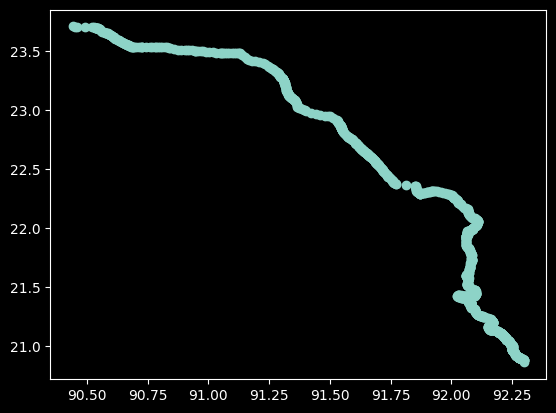

In [20]:
import matplotlib.pyplot as plt

plt.scatter(final_df_with_links['lon'], final_df_with_links['lat'])
plt.show()

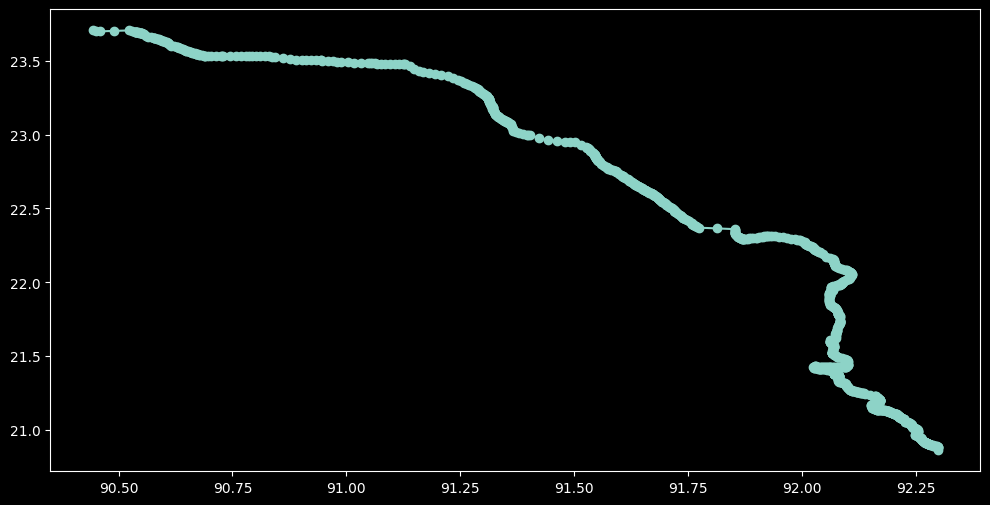

In [21]:
plt.figure(figsize=(12,6))
plt.plot(final_df_with_links['lon'], final_df_with_links['lat'], marker='o')
plt.show()

In [22]:
final_df_with_links.to_csv('../data/data_N1.csv', na_rep="None")